<a href="https://colab.research.google.com/github/manojmulammagari/ML-DL-Practice/blob/main/Understanding_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd

In [11]:
df = pd.read_csv('tested.csv')

In [12]:
df.shape

(418, 12)

In [13]:
df.head()

df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
111,1003,1,3,"Shine, Miss. Ellen Natalia",female,NaN,0,0,330968,7.7792,NaN,Q
327,1219,0,1,"Rosenshine, Mr. George (Mr George Thorne"")""",male,46.0,0,0,PC 17585,79.2000,NaN,C
14,906,1,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.1750,E31,S
403,1295,0,1,"Carrau, Mr. Jose Pedro",male,17.0,0,0,113059,47.1000,NaN,S
59,951,1,1,"Chaudanson, Miss. Victorine",female,36.0,0,0,PC 17608,262.3750,B61,C


### Data Preprocessing for Machine Learning

To prepare the data for machine learning, we need to address missing values, handle categorical features, and drop columns that are not useful for modeling.

In [14]:
# 1. Re-load the fresh data to fix the corrupted state
df = pd.read_csv('tested.csv')

# 2. Correct imputation
age_median = df['Age'].median()
fare_median = df['Fare'].median()
df['Age'] = df['Age'].fillna(age_median)
df['Fare'] = df['Fare'].fillna(fare_median)

# 3. Drop columns
df.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True, errors='ignore')

# 4. Encoding
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("Missing values check:")
print(df.isnull().sum())
print("\nData Preview:")
display(df.head())

Missing values check:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_Q     0
Embarked_S     0
dtype: int64

Data Preview:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,892,0,3,0,34.5,0,0,7.8292,True,False
1,893,1,3,1,47.0,1,0,7.0000,False,True
2,894,0,2,0,62.0,0,0,9.6875,True,False
3,895,0,3,0,27.0,0,0,8.6625,False,True
4,896,1,3,1,22.0,1,1,12.2875,False,True


Finally, let's review the data types to ensure all features are numerical and ready for machine learning.

In [15]:
print("Data types after all preprocessing steps:")
display(df.info())

Data types after all preprocessing steps:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Sex          418 non-null    int64  
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Fare         418 non-null    float64
 8   Embarked_Q   418 non-null    bool   
 9   Embarked_S   418 non-null    bool   
dtypes: bool(2), float64(2), int64(6)
memory usage: 27.1 KB


None

### Splitting Data into Training and Testing Sets

Before training any machine learning model, it's crucial to split the data into a training set and a testing set. The training set will be used to teach the model, and the testing set will be used to evaluate its performance on unseen data. We'll separate the features (X) from the target variable (y), which is 'Survived' in this case.

In [16]:
from sklearn.model_selection import train_test_split

# Exclude PassengerId and Sex to see the impact of other features
X = df.drop(['Survived', 'PassengerId', 'Sex'], axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")

X_train shape: (334, 7)


Now that the data is split, we can proceed to train a machine learning model. Which model would you like to use? A common starting point is a Logistic Regression model.

### Training a Logistic Regression Model

We will now train a Logistic Regression model using the training data (`X_train`, `y_train`). This model will learn to predict the 'Survived' status based on the input features.

In [17]:
from sklearn.linear_model import LogisticRegression

# Initialize and train on cleaned data
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)

print("Model trained successfully on cleaned data.")

Model trained successfully on cleaned data.


### Evaluating Model Accuracy

Now that the model is trained, we can evaluate its performance on the unseen test data (`X_test`, `y_test`). Accuracy is a common metric for classification tasks, representing the proportion of correctly predicted instances.

In [18]:
from sklearn.metrics import accuracy_score

# Predict and check accuracy without 'Sex' column on cleaned data
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Updated Accuracy (excluding 'Sex'): {accuracy:.4f}")

Updated Accuracy (excluding 'Sex'): 0.5952


### Detailed Performance Analysis

To better understand the 100% accuracy, let's examine the classification report and the confusion matrix. This will show us if the model is performing perfectly across all classes.

Classification Report (No 'Sex' feature):
              precision    recall  f1-score   support

           0       0.60      0.94      0.73        50
           1       0.50      0.09      0.15        34

    accuracy                           0.60        84
   macro avg       0.55      0.51      0.44        84
weighted avg       0.56      0.60      0.50        84



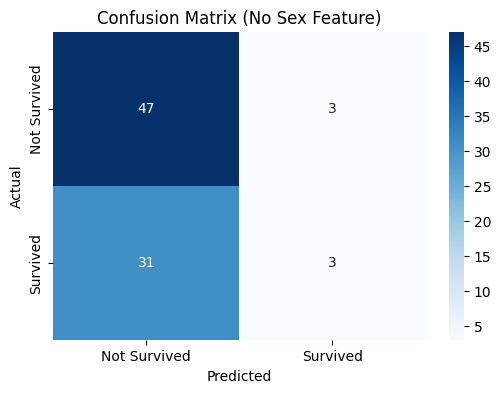

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluation after data fix
print("Classification Report (No 'Sex' feature):")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (No Sex Feature)')
plt.show()